# Báo cáo bài tập thực hành tuần 4
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Chiều thứ 6, ca 1)

Import các thư viện cần thiết

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder


### 1. Cài đặt thuật toán Apriori

Phần này làm giống như trong file thực hành

In [19]:
# Load dữ liệu
df = pd.read_csv(r'D:\Data-Mining_MTH10358\Homeworks\TH\4\data.csv', header=None)
df

,0,1,2,3,4,5
0,Wine,Chips,Bread,Butter,Milk,Apple
1,Wine,NaN,Bread,Butter,Milk,NaN
2,NaN,NaN,Bread,Butter,Milk,NaN
3,NaN,Chips,NaN,NaN,NaN,Apple
4,Wine,Chips,Bread,Butter,Milk,Apple
5,Wine,Chips,NaN,NaN,Milk,NaN
6,Wine,Chips,Bread,Butter,NaN,Apple
7,Wine,Chips,NaN,NaN,Milk,NaN
8,Wine,NaN,Bread,NaN,NaN,Apple
9,Wine,NaN,Bread,Butter,Milk,NaN


Chuyển DataFrame thành dạng danh sách (list)

In [20]:
records = []
for i in range(0, df.shape[0]):
    records.append([str(df.values[i,j]) for j in range(0, df.shape[1])])

Chuyển records thành dạng transaction <br>
**Extra:** Xóa cột nan sau khi đã chuyển sang dạng transaction

In [21]:
# chuyển records thành transaction
te = TransactionEncoder()
te_ary = te.fit(records).transform(records)
df1 = pd.DataFrame(te_ary, columns=te.columns_)
print(df1)

# Extra remove nan column
df1 = df1.drop(columns=['nan'])
df1

    Apple  Bread  Butter  Chips   Milk   Wine    nan
0    True   True    True   True   True   True  False
1   False   True    True  False   True   True   True
2   False   True    True  False   True  False   True
3    True  False   False   True  False  False   True
4    True   True    True   True   True   True  False
5   False  False   False   True   True   True   True
6    True   True    True   True  False   True   True
7   False  False   False   True   True   True   True
8    True   True   False  False  False   True   True
9   False   True    True  False   True   True   True
10   True   True    True   True  False  False   True
11   True  False    True  False   True   True   True
12  False   True    True   True   True   True   True
13   True   True   False  False   True   True   True
14   True   True    True  False   True   True   True
15   True   True    True   True   True   True  False
16   True   True    True   True   True  False   True
17   True  False    True   True   True  False 

,Apple,Bread,Butter,Chips,Milk,Wine
0,True,True,True,True,True,True
1,False,True,True,False,True,True
2,False,True,True,False,True,False
3,True,False,False,True,False,False
4,True,True,True,True,True,True
5,False,False,False,True,True,True
6,True,True,True,True,False,True
7,False,False,False,True,True,True
8,True,True,False,False,False,True
9,False,True,True,False,True,True



Xây dựng mô hình Apriori

In [22]:
frequent_itemsets = apriori(df1, min_support=0.6, use_colnames=True)
print(frequent_itemsets)

    support      itemsets
0  0.681818       (Apple)
1  0.727273       (Bread)
2  0.681818      (Butter)
3  0.636364       (Chips)
4  0.772727        (Milk)
5  0.727273        (Wine)
6  0.636364  (Milk, Wine)


In kết quả

In [23]:
# build association rules using support metric
rules = association_rules(frequent_itemsets, metric="support", support_only=True,
                          min_threshold=0.1)

rules = rules[['antecedents', 'consequents', 'support']]
print(rules)

  antecedents consequents   support
0      (Milk)      (Wine)  0.636364
1      (Wine)      (Milk)  0.636364


**Cài đặt thuật toán Apriori**

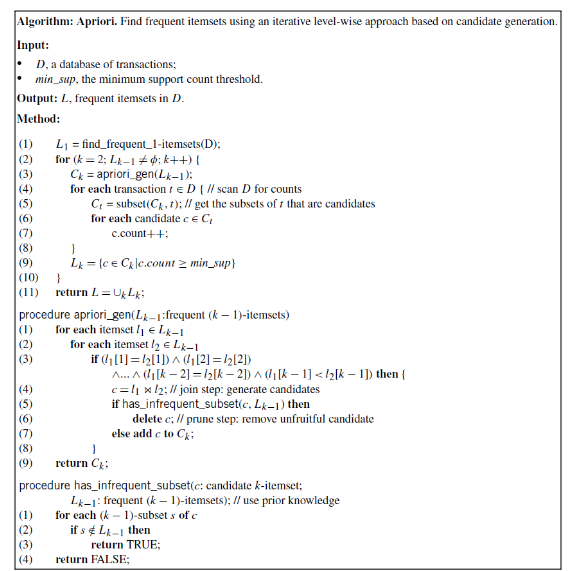

In [24]:
def has_infrequent_subset(D, Lk_1):
    for item in D:
        subset = D - frozenset([item])
        if subset not in Lk_1:
            return True
            
    return False

def apriori_gen(Lk_1, k):
    Ck = set()
    Lk_1_list = list(Lk_1)
    
    for i in range(len(Lk_1_list)):
        for j in range(i + 1, len(Lk_1_list)):
            l1 = list(Lk_1_list[i])
            l2 = list(Lk_1_list[j])
            l1.sort()
            l2.sort()
            
            if l1[:k-2] == l2[:k-2] and l1[k-2] != l2[k-2]:
                candidate = frozenset(l1) | frozenset(l2)
                
                if not has_infrequent_subset(candidate, Lk_1):
                    Ck.add(candidate)
    return Ck

def apriori_homecooked(candidate, min_support):
    num_candidate = len(candidate)
    min_count = min_support * num_candidate 
    
    trans_sets = [set(t) for t in candidate]
    
    all_frequent_itemsets = {}
    
    item_counts = {}
    for t in trans_sets:
        for item in t:
            if str(item) != 'nan': 
                item_counts[frozenset([item])] = item_counts.get(frozenset([item]), 0) + 1
                
    L1 = {itemset: count for itemset, count in item_counts.items() if count >= min_count}
    all_frequent_itemsets.update(L1)
    
    Lk_1 = L1
    k = 2
    
    while Lk_1:
        Ck = apriori_gen(Lk_1.keys(), k)
        
        Ck_counts = {c: 0 for c in Ck}
        for t in trans_sets:
            for candidate in Ck:
                if candidate.issubset(t):
                    Ck_counts[candidate] += 1
                    
        Lk = {c: count for c, count in Ck_counts.items() if count >= min_count}
        
        if not Lk:
            break
            
        all_frequent_itemsets.update(Lk)
        Lk_1 = Lk
        k += 1
        
    result = []
    for itemset, count in all_frequent_itemsets.items():
        support = count / num_candidate
        result.append({
            'support': support,
            'itemsets': set(itemset)
        })
        
    return result



Hàm `has_infrequent_subset` kiểm tra xem một tập con có phải là tập con không phổ biến hay không. Hoạt động theo cách bước sau:
1. Duyệt qua từng phần tử trong tập D.
2. Tạo một tập con bằng cách loại bỏ phần tử hiện tại khỏi D.
3. Kiểm tra xem tập con này có tồn tại trong Lk_1 hay không. Nếu không tồn tại, trả về True (có tập con không phổ biến).
4. Nếu tất cả các tập con đều phổ biến, trả về False.
```python
def has_infrequent_subset(D, Lk_1):
    for item in D:
        subset = D - frozenset([item])
        if subset not in Lk_1:
            return True
            
    return False
```
Hàm `apriori_gen` tạo ra các ứng viên tập phổ biến k từ tập phổ biến k-1. Hoạt động theo cách bước sau:
1. Tạo một tập rỗng Ck để lưu trữ các ứng viên.
2. Chuyển Lk_1 thành một danh sách để dễ dàng truy cập.
3. Duyệt qua tất cả các cặp tập phổ biến k-1 (l1 và l2).
4. So sánh phần đầu của hai tập (k-2 phần tử đầu tiên). Nếu chúng giống nhau và phần tử cuối cùng khác nhau, tạo một ứng viên mới bằng cách hợp nhất hai tập.
5. Kiểm tra xem ứng viên mới có chứa tập con không phổ biến hay không bằng cách gọi hàm `has_infrequent_subset`. Nếu không có tập con không phổ biến, thêm ứng viên vào Ck.
6. Trả về tập ứng viên Ck.
```python
def apriori_gen(Lk_1, k):
    Ck = set()
    Lk_1_list = list(Lk_1)
    
    for i in range(len(Lk_1_list)):
        for j in range(i + 1, len(Lk_1_list)):
            l1 = list(Lk_1_list[i])
            l2 = list(Lk_1_list[j])
            l1.sort()
            l2.sort()
            
            if l1[:k-2] == l2[:k-2] and l1[k-2] != l2[k-2]:
                candidate = frozenset(l1) | frozenset(l2)
                
                if not has_infrequent_subset(candidate, Lk_1):
                    Ck.add(candidate)
    return Ck
```
Hàm `apriori_homecooked` thực hiện thuật toán Apriori. Hoạt động theo cách bước sau:
1. Tính số lượng giao dịch và số lượng tối thiểu dựa trên ngưỡng hỗ trợ. <br>
    1.1. `num_candidate` là số lượng giao dịch trong tập dữ liệu. <br>
    1.2. `min_count` là số lượng tối thiểu cần thiết để một tập phổ biến được coi là phổ biến, được tính bằng cách nhân `min_support` với `num_candidate`.
2. Chuyển đổi các giao dịch thành tập hợp để dễ dàng kiểm tra tập con.
3. Đếm tần suất của các mục đơn lẻ (L1). <br>
    3.1. Duyệt qua từng giao dịch và đếm số lần xuất hiện của mỗi mục. <br>
    3.2. Lọc ra các mục phổ biến dựa trên số lượng tối thiểu.

4. Sử dụng vòng lặp để tạo các ứng viên tập phổ biến k từ Lk_1 và đếm tần suất của chúng trong các giao dịch. <br>
    4.1. Tạo tập ứng viên Ck bằng cách gọi hàm `apriori_gen`. <br>
    4.2. Đếm tần suất của các ứng viên trong Ck bằng cách kiểm tra xem chúng có phải là tập con của các giao dịch hay không.
5. Lọc ra các tập phổ biến k (Lk) và tiếp tục cho đến khi không còn tập phổ biến nào nữa.
6. Tính toán hỗ trợ cho tất cả các tập phổ biến và trả về kết quả dưới dạng danh sách các từ điển chứa hỗ trợ và tập phổ biến.
```python
def apriori_homecooked(candidate, min_support):
    num_candidate = len(candidate)
    min_count = min_support * num_candidate 
    
    trans_sets = [set(t) for t in candidate]
    
    all_frequent_itemsets = {}
    
    item_counts = {}
    for t in trans_sets:
        for item in t:
            if str(item) != 'nan': 
                item_counts[frozenset([item])] = item_counts.get(frozenset([item]), 0) + 1
                
    L1 = {itemset: count for itemset, count in item_counts.items() if count >= min_count}
    all_frequent_itemsets.update(L1)
    
    Lk_1 = L1
    k = 2
    
    while Lk_1:
        Ck = apriori_gen(Lk_1.keys(), k)
        
        Ck_counts = {c: 0 for c in Ck}
        for t in trans_sets:
            for candidate in Ck:
                if candidate.issubset(t):
                    Ck_counts[candidate] += 1
                    
        Lk = {c: count for c, count in Ck_counts.items() if count >= min_count}
        
        if not Lk:
            break
            
        all_frequent_itemsets.update(Lk)
        Lk_1 = Lk
        k += 1
        
    result = []
    for itemset, count in all_frequent_itemsets.items():
        support = count / num_candidate
        result.append({
            'support': support,
            'itemsets': set(itemset)
        })
        
    return result
```


In [25]:
dataset = [
    ["Wine", "Chips", "Bread", "Butter", "Milk", "Apple"],  
    ["Wine", "Bread", "Butter", "Milk"],                    
    ["Bread", "Butter", "Milk"],                            
    ["Chips", "Apple"],                                     
    ["Wine", "Chips", "Bread", "Butter", "Milk", "Apple"],  
    ["Wine", "Chips", "Milk"],                              
    ["Wine", "Chips", "Bread", "Butter", "Apple"],          
    ["Wine", "Chips", "Milk"],                              
    ["Wine", "Bread", "Apple"],                             
    ["Wine", "Bread", "Butter", "Milk"],                    
    ["Chips", "Bread", "Butter", "Apple"],                  
    ["Wine", "Butter", "Milk", "Apple"],                    
    ["Wine", "Chips", "Bread", "Butter", "Milk"],           
    ["Wine", "Bread", "Milk", "Apple"],                     
    ["Wine", "Bread", "Butter", "Milk", "Apple"],           
    ["Wine", "Chips", "Bread", "Butter", "Milk", "Apple"],  
    ["Chips", "Bread", "Butter", "Milk", "Apple"],          
    ["Chips", "Butter", "Milk", "Apple"],                   
    ["Wine", "Chips", "Bread", "Butter", "Milk", "Apple"],  
    ["Wine", "Bread", "Butter", "Milk", "Apple"],           
    ["Wine", "Chips", "Bread", "Milk", "Apple"],            
    ["Chips"]                                               
]
frequent_items = apriori_homecooked(dataset, min_support=0.6)

# Homecooked
df_result = pd.DataFrame(frequent_items)
print(df_result)

# Premade
frequent_itemsets = apriori(df1, min_support=0.6, use_colnames=True)
print(frequent_itemsets)

    support      itemsets
0  0.727273        {Wine}
1  0.727273       {Bread}
2  0.772727        {Milk}
3  0.681818      {Butter}
4  0.681818       {Apple}
5  0.636364       {Chips}
6  0.636364  {Milk, Wine}
    support      itemsets
0  0.681818       (Apple)
1  0.727273       (Bread)
2  0.681818      (Butter)
3  0.636364       (Chips)
4  0.772727        (Milk)
5  0.727273        (Wine)
6  0.636364  (Milk, Wine)


Như vậy kết quả giống y chang với hàm có sẵn trong thư viện mlxtend.